# 01 — Data exploration

Sanity-check the synthetic dataset: distributions, hierarchy, churn rate, and target-leakage tests.
If you haven't generated yet, run from the project root:

```
uv run python -m src.cli generate
```

In [1]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent if (pathlib.Path('.').resolve().name == 'notebooks') else pathlib.Path('.').resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import pipeline

DATA_DIR = ROOT / 'data' / 'synthetic'
customers = pd.read_parquet(DATA_DIR / 'customers.parquet')
targets = pd.read_parquet(DATA_DIR / 'targets.parquet')
tx = pd.read_parquet(DATA_DIR / 'transactions_monthly.parquet')
print(f'customers={len(customers):,}  transactions={len(tx):,}  churn rate={targets.churn_next_12m.mean():.1%}')

customers=50,000  transactions=1,486,501  churn rate=13.8%


## Customer hierarchy and target distribution

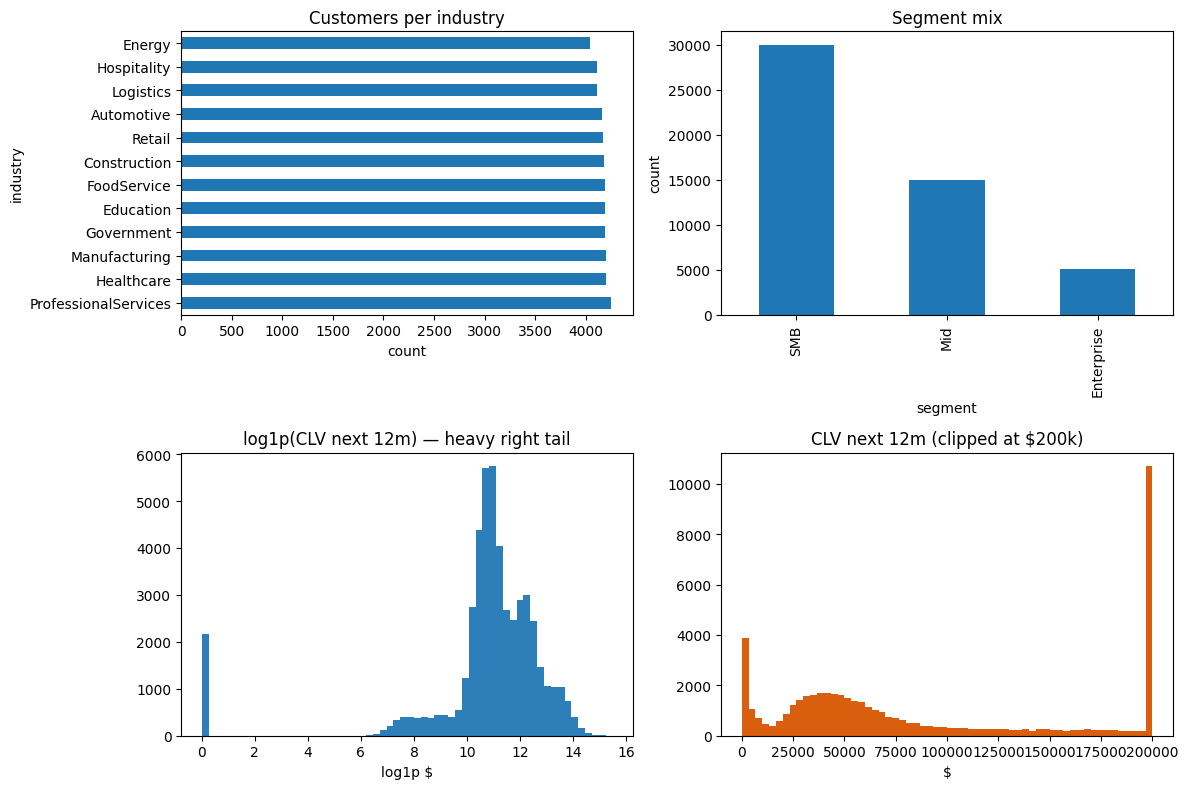

count      50000.00
mean      151962.77
std       246754.86
min            0.00
25%        34156.18
50%        61195.32
75%       168822.16
max      5280620.00
Name: clv_next_12m_usd, dtype: float64


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
customers.industry.value_counts().plot(kind='barh', ax=axes[0,0], title='Customers per industry'); axes[0,0].set_xlabel('count')
customers.segment.value_counts().plot(kind='bar', ax=axes[0,1], title='Segment mix'); axes[0,1].set_ylabel('count')
axes[1,0].hist(np.log1p(targets.clv_next_12m_usd), bins=60, color='#2c7fb8'); axes[1,0].set_title('log1p(CLV next 12m) — heavy right tail'); axes[1,0].set_xlabel('log1p $')
axes[1,1].hist(targets.clv_next_12m_usd.clip(0, 200_000), bins=60, color='#d95f0e'); axes[1,1].set_title('CLV next 12m (clipped at $200k)'); axes[1,1].set_xlabel('$')
fig.tight_layout(); plt.show()
print(targets.clv_next_12m_usd.describe().round(2))

## Sequence inspection: how active is the average customer?

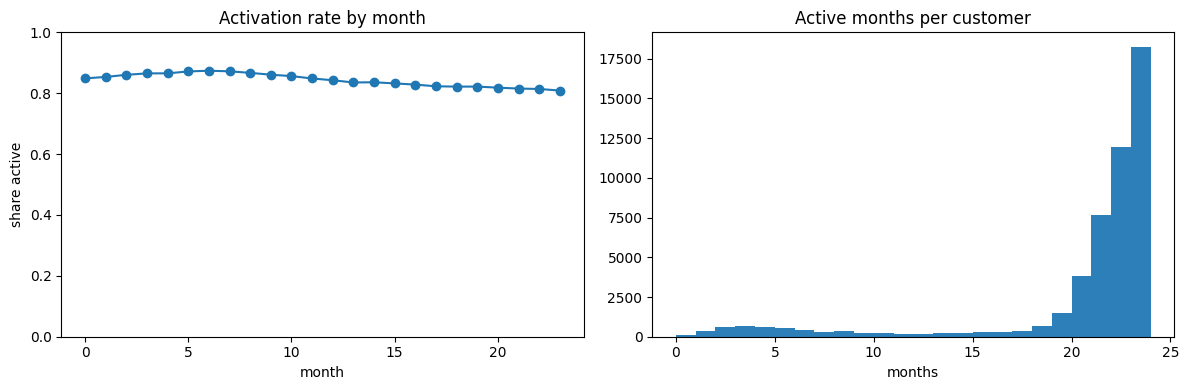

In [3]:
import numpy as np
dense = np.load(DATA_DIR / 'dense_input.npz')
active = dense['active']  # (n, 24)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(active.mean(axis=0), marker='o'); axes[0].set_title('Activation rate by month'); axes[0].set_xlabel('month'); axes[0].set_ylabel('share active'); axes[0].set_ylim(0, 1)
axes[1].hist(active.sum(axis=1), bins=24, color='#2c7fb8'); axes[1].set_title('Active months per customer'); axes[1].set_xlabel('months')
fig.tight_layout(); plt.show()

## Sanity: target depends on history (no leakage in either direction)

            last12  next12_clv
last12        1.00        0.83
next12_clv    0.83        1.00


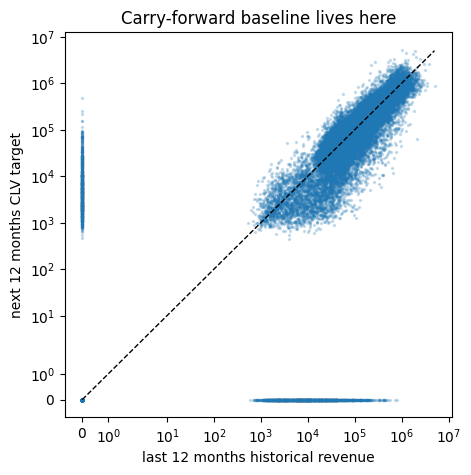

In [4]:
# Compare last-12 historical revenue to next-12 CLV. They should correlate but not equal.
last12_rev = np.expm1(np.log1p(dense['revenue']))[:, -12:].sum(axis=1)
merged = pd.DataFrame({'last12': last12_rev, 'next12_clv': targets.clv_next_12m_usd.values})
print(merged.corr().round(3))
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(merged.last12, merged.next12_clv, s=2, alpha=0.2)
ax.plot([0, merged.last12.max()], [0, merged.last12.max()], 'k--', lw=1)
ax.set_xlabel('last 12 months historical revenue'); ax.set_ylabel('next 12 months CLV target'); ax.set_xscale('symlog'); ax.set_yscale('symlog')
ax.set_title('Carry-forward baseline lives here')
plt.show()